# Botond's Notebook

This notebook contains analysis related to the pope nodes and hidden figures focusing on wordclouds and bridges between pope nodes, famous people and eras. Most of the experiments that were unrelated or the results turned out to be not relevant to the main arch of the research were éeft out from this version.

## Imports

In [ ]:
import networkx as nx
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string
import math
from collections import Counter
from typing import Dict, Any
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import difflib
import pandas as pd
from networkx.algorithms.centrality import betweenness_centrality_subset

## Network Preparation

In [231]:
network = nx.read_graphml("celebrities_clean_without_content.graphml")

Defining our different eras which we will investigate, we have 7 eras in total, with an additional unknown bucket.

In [232]:
periods = [
    (-float('inf'), 30, "Before Christ"),
    (30, 476, "Classical Era"),
    (476, 1450, "Middle Ages"),
    (1450, 1760, "Early Modern Era"),
    (1760, 1840, "Industrial Era"),
    (1840, 1945, "Wartime Era"),
    (1945, 2025, "Post-War Era"),
    (2025, float('inf'), "Unknown")
]

We create subgraphs for each of our eras from the main graphs using networkx. We define a person being included in an era if their birthyear is within an era. This way each person is only present in one single era.

In [233]:
era_subgraphs = {}
for start, end, label in periods:

    subgraph = network.subgraph([n for n, attr in network.nodes(data=True) if (attr.get("birthyear") <= end) and attr.get("birthyear") >= start])
    print(f"Period: {label}, Number of nodes: {subgraph.number_of_nodes()}")
    era_subgraphs[label] = subgraph

Period: Before Christ, Number of nodes: 534
Period: Classical Era, Number of nodes: 308
Period: Middle Ages, Number of nodes: 876
Period: Early Modern Era, Number of nodes: 889
Period: Industrial Era, Number of nodes: 751
Period: Wartime Era, Number of nodes: 4051
Period: Post-War Era, Number of nodes: 3982
Period: Unknown, Number of nodes: 0


In [234]:
def node_by_name(G, name):
    for n in G.nodes:
        if getattr(n, "name", None) == name:
            return n

Next we collect all of the popes corresponding to our era definitions. The filtering is done with the title (in the name) and occupation as RELIGIOUS FIGURE.

In [235]:
popes_in_periods = {}
for period, subgraph in era_subgraphs.items():
    pope_nodes = [
        (n, attr) for n, attr in subgraph.nodes(data=True)
        if isinstance(attr.get("Name"), str) and "Pope" in attr.get("Name") and attr.get("occupation") == "RELIGIOUS FIGURE"
    ]
    popes_in_periods[period] = pope_nodes
    print(f"Period: {period}, Number of popes: {len(pope_nodes)}")


Period: Before Christ, Number of popes: 4
Period: Classical Era, Number of popes: 50
Period: Middle Ages, Number of popes: 157
Period: Early Modern Era, Number of popes: 35
Period: Industrial Era, Number of popes: 6
Period: Wartime Era, Number of popes: 9
Period: Post-War Era, Number of popes: 0
Period: Unknown, Number of popes: 0


In [236]:
def get_undirected_neighbors(node, network):
    """
    Returns a list of neighbors for a specific node
    """
    # Check if the node exists to avoid generic errors later
    if node not in network:
        raise ValueError(f"Node {node} not found in the network.")

    if network.is_directed():

        in_neighbors = set(network.predecessors(node))
        out_neighbors = set(network.successors(node))

        # combine successors and predecessors
        return list(in_neighbors | out_neighbors)
    else:
        return list(network.neighbors(node))

In [237]:
def get_wikilink_content(node_id, network, folder_path="wikipages"):
    
    # Check if node exists in the network
    if node_id not in network:
        raise ValueError(f"Node ID '{node_id}' not found in the network.")

    node_data = network.nodes[node_id]
    name_url = node_data.get("NameURL")
    
    if not name_url:
        raise ValueError(f"Node '{node_id}' does not have a 'NameURL' attribute.")
    
    # Construct the file path
    filename = f"{name_url}.txt"
    file_path = os.path.join(folder_path, filename)
    
    # Read and return the file content
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        return None  # Return None instead of crashing if unexpectedly the file is not found
    except IOError as e:
        raise IOError(f"Error reading file {file_path}: {e}")


As now we have the popes sorted within our era buckets, we start preparing the texts to the wordclouds. Our approach is to get a wordcloud around each era of popes. We use the network to get the immediate connections to each pope and then gather their wikipedia texts. These are going to be used to generate the wordclouds for each era. The reason for this approach is that contrary to only selecting the wikipedia texts of the popes which are quite similar even across eras, we instead look at the articles of the people associated with them which in our hopes would give a better impression on how the popes are embedded into each era.

## Wordclouds

In [238]:
# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\boton\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


The wikipedia texts need to be cleaned and tokenized. For this we have taken our approach from one of the previous submissions and refined it. The regular expressions remove html tags, comments and most fields that contain metadata.

In [239]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    
    # Remove Refs/Citations first (content inside <ref> is usually not main text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    
    # Remove HTML comments
    text = re.sub(r'', '', text, flags=re.DOTALL)
    
    # Remove URLs (keep this aggressive as per your request)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove File/Image/Category links completely (e.g., [[File:Image.jpg]])
    text = re.sub(r'\[\[(File|Category|Image):[^\]]+\]\]', '', text, flags=re.IGNORECASE)

    # Handle Wikilinks: [[Target|Display]] - keep "Display". [[Target]] - keep "Target"
    # This regex looks for optional text before a pipe |, and captures what follows.
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)

    # Remove Templates.
    text = re.sub(r'\{\{[^}]+\}\}', '', text)
    
    # Remove remaining HTML tags but keep content between them
    text = re.sub(r'<[^>]+>', ' ', text)

    # Lowercase
    text = text.lower()
    
    # Handle Punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    
    # Remove extra whitespace created by replacements
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    cleaned_tokens = []
    
    for token in tokens:
        # Skip stop words
        if token in stop_words:
            continue
        
        # Skip digits/special chars (keep only alphabetic)
        if not token.isalpha():
            continue
            
        # Adjusted Length filter
        if len(token) < 2: 
            continue
        if len(token) > 20:
            continue
            
        # Lemmatize
        lemmatized = lemmatizer.lemmatize(token)
        cleaned_tokens.append(lemmatized)

    return cleaned_tokens

Our initial approach was to create wordclouds from the raw frequencies of words appearing in the concatenated wikipedia texts. The results of this approach included plenty of similarities and did not capture the characteristics of the different eras. Additionally, some of the most common words were 'also' and 'would' which are equally present in almost all texts and hold no specific meaning to an era. Because of this as a next experiment we introduced the TF-IDF based approach which was introduced in one of the lectures. Our way of calculating the scores is the following:

### TF–IDF Calculation Formulas

TF–IDF measures how important a word is within a document (all texts aggregated for an era) compared to all documents (all era texts).

- **t** = a term (word)
- **d** = a specific document
- **D** = the full set of documents
- **N** = total number of documents (`len(D)`)
- **count(t, d)** = number of times term *t* is present in document *d*
- **total_terms(d)** = total number of tokens in document *d*
- **DF(t)** = number of documents that contain term *t* (document frequency)
- **min_df** = minimum number of documents a term must appear in (filter)

**Term Frequency (TF):**
$$
\text{TF}(t,d) = \frac{\text{count}(t,d)}{\text{total\_terms}(d)}
$$

**Document Frequency (DF):**
$$
\text{DF}(t) = |\{ d \in D : t \in d \}|
$$

**IDF (computed only when } \text{DF}(t) \ge \text{min\_df} \text{):**
$$
\text{IDF}(t) = \ln\left( \frac{N}{\text{DF}(t)} \right)
$$

**TF–IDF Weight:**
$$
\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)
$$


In [240]:
def compute_tf_idf(documents_dict: Dict[Any, str], min_df: int = 2) -> Dict[Any, Dict[str, float]]:

    n_documents = len(documents_dict)
    
    # Stores (term_counts, total_tokens) per document
    doc_data = {} 
    
    # Tracks how many documents contain a specific term
    global_doc_freq = Counter()

    # Tokenize and Count
    for doc_id, text in documents_dict.items():
        tokens = clean_and_tokenize(text)
        
        if not tokens:
            doc_data[doc_id] = (Counter(), 0)
            continue

        term_counts = Counter(tokens)
        doc_data[doc_id] = (term_counts, len(tokens))
        
        # Update document frequency (set ensures we count presence only once per doc)
        global_doc_freq.update(term_counts.keys())

    # Calculate IDF (Pre-computation)
    idf_lookup = {
        term: math.log(n_documents / df)
        for term, df in global_doc_freq.items()
        if df >= min_df
    }

    tf_idf_matrix = {}

    for doc_id, (term_counts, total_terms) in doc_data.items():
        doc_vector = {}
        
        # Only process if document is not empty
        if total_terms > 0:
            for term, count in term_counts.items():
                # Only calculate if term exists in our filtered IDF lookup
                if term in idf_lookup:
                    tf = count / total_terms
                    idf = idf_lookup[term]
                    doc_vector[term] = tf * idf
        
        tf_idf_matrix[doc_id] = doc_vector

    return tf_idf_matrix

To make our filtering more robust we remove some context specific stop words which are present in the majority of the eras

In [241]:
def filter_and_update_corpus(documents_dict, max_doc_freq=0.6):

    from collections import Counter
    
    # Temporary storage to avoid tokenizing twice
    tokenized_docs = {} 
    doc_counts = Counter()
    total_docs = len(documents_dict)
    
    # Tokenize and Count
    for doc_id, text in documents_dict.items():
        tokens = clean_and_tokenize(text)
        
        # Update global counts (using set so we count document frequency, not term frequency)
        unique_tokens = set(tokens)
        doc_counts.update(unique_tokens)
        
        # Store tokens
        tokenized_docs[doc_id] = tokens

    # Identify the éist to be ignored (stopwords)
    ignore_set = {term for term, count in doc_counts.items() 
                  if (count / total_docs) > max_doc_freq}
    
    print(f"Auto-detected {len(ignore_set)} specific stopwords (appearing in >{int(max_doc_freq*100)}% of docs).")
    if len(ignore_set) > 0:
        print(f"Examples removed: {list(ignore_set)[:5]}")

    # Rebuild the dictionary
    cleaned_documents = {}
    
    for doc_id, tokens in tokenized_docs.items():
        # Filter out the bad words
        filtered_tokens = [t for t in tokens if t not in ignore_set]
        
        # Join back into a string 
        cleaned_documents[doc_id] = " ".join(filtered_tokens)

    return cleaned_documents

In [242]:
def create_wordcloud_from_tokens(tokens, title="Word Cloud", colormap='viridis'):

    if not tokens or len(tokens) == 0:
        print("Cannot generate WordCloud: Input token list is empty.")
        return
    tokens = [str(t).strip() for t in tokens if '\n' not in str(t)]

    word_counts = Counter(tokens)

    # Configure WordCloud
    wc = WordCloud(
        width=1200, 
        height=800,
        background_color='white',
        colormap=colormap,
        max_words=150,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_counts)

    # Plotting
    plt.figure(figsize=(12, 10))
    plt.imshow(wc, interpolation='bilinear')
    
    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [243]:
def create_tfidf_wordcloud(tf_idf_matrix, doc_id=None, title="TF-IDF Word Cloud", colormap='viridis'):

    if doc_id is not None:
        if doc_id not in tf_idf_matrix:
            print(f"Error: Document ID '{doc_id}' not found in matrix.")
            return
        weights = tf_idf_matrix[doc_id]
        if not title: title = f"TF-IDF Cloud: {doc_id}"
        
    # find globally important terms
    else:
        weights = Counter()
        for doc_vec in tf_idf_matrix.values():
            weights.update(doc_vec)

    # Safety Check
    if not weights:
        print("Cannot generate WordCloud: Input weight dictionary is empty.")
        return

    # Configure WordCloud
    # We use generate_from_frequencies because we already have the calculated weights
    wc = WordCloud(
        width=1200, 
        height=800,
        background_color='white',
        colormap=colormap,
        max_words=150,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(weights)

    # Plotting
    plt.figure(figsize=(12, 10))
    plt.imshow(wc, interpolation='bilinear')
    
    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [244]:
def get_wordcloud_of_pope_era(era):
    jumbo_tokens = []
    target_popes = popes_in_periods[era]
    for pope in target_popes:
        neighbors = get_undirected_neighbors(pope[0], network)
        for n in neighbors:
            relevant_tokens = clean_and_tokenize(get_wikilink_content(n, network))
            jumbo_tokens += relevant_tokens

    create_wordcloud_from_tokens(jumbo_tokens, title=f"Keywords for {era} popes", colormap='viridis')


As visible here, generating the raw wordlouds for 2 distinctive eras gives a significant amount of overlaps.

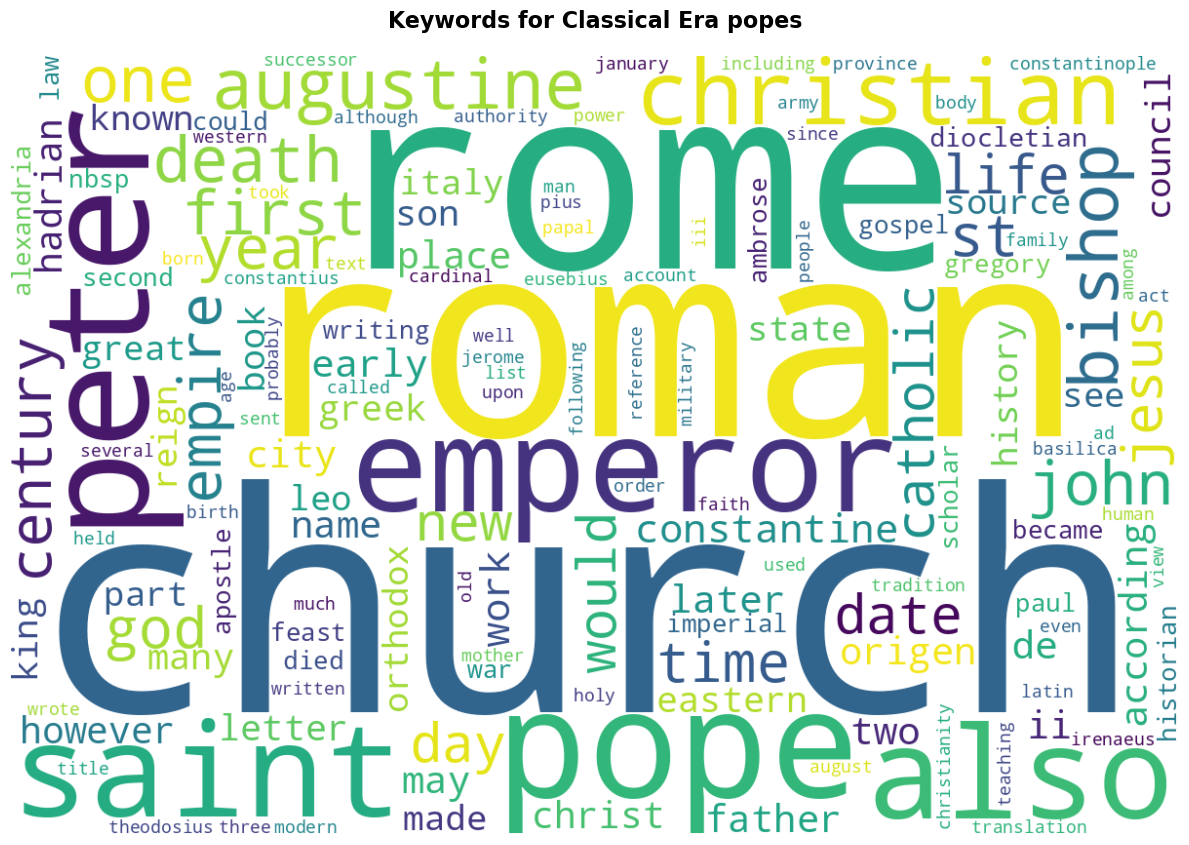

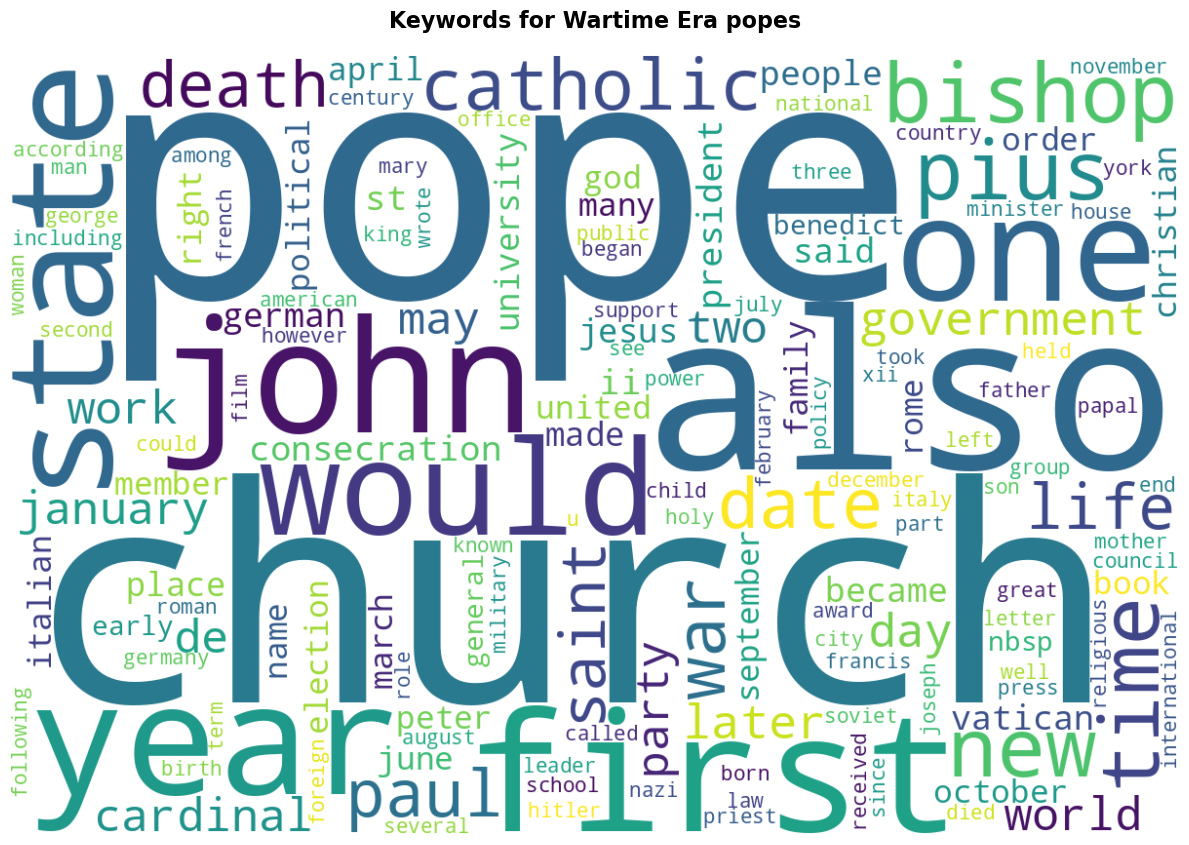

In [245]:
get_wordcloud_of_pope_era("Classical Era")
get_wordcloud_of_pope_era("Wartime Era")

In [246]:
def visualize_all_pope_eras(popes_in_periods, network):

    era_documents = {}

    # Loop through all available eras
    for era, popes in popes_in_periods.items():
        
        # collect all raw text
        era_raw_text_chunks = []
        
        for pope in popes:

            pope_id = pope[0]
            
            neighbors = get_undirected_neighbors(pope_id, network)
            
            for n in neighbors:
                # Get the raw content string
                content = get_wikilink_content(n, network)
                if content:
                    era_raw_text_chunks.append(str(content))
        
        # Join all text chunks to form one "Document" representing the whole Era
        era_documents[era] = " ".join(era_raw_text_chunks)

    era_documents = filter_and_update_corpus(era_documents, max_doc_freq=0.7)

 
    # Terms appearing in ALL eras (high Document Frequency) should get a lower score
    tf_idf_matrix = compute_tf_idf(era_documents, min_df=1)

    for era, vec in list(tf_idf_matrix.items()):
        if not vec:
            continue
        max_v = max(vec.values())
        if max_v > 0:
            tf_idf_matrix[era] = {k: v / max_v for k, v in vec.items()}
            
    for era in era_documents.keys():
        create_tfidf_wordcloud(
            tf_idf_matrix, 
            doc_id=era, 
            title=f"Distinctive Keywords: {era}",
            colormap='viridis'
        )

Auto-detected 7541 specific stopwords (appearing in >70% of docs).
Examples removed: ['abortive', 'foiled', 'oppressive', 'vi', 'propose']


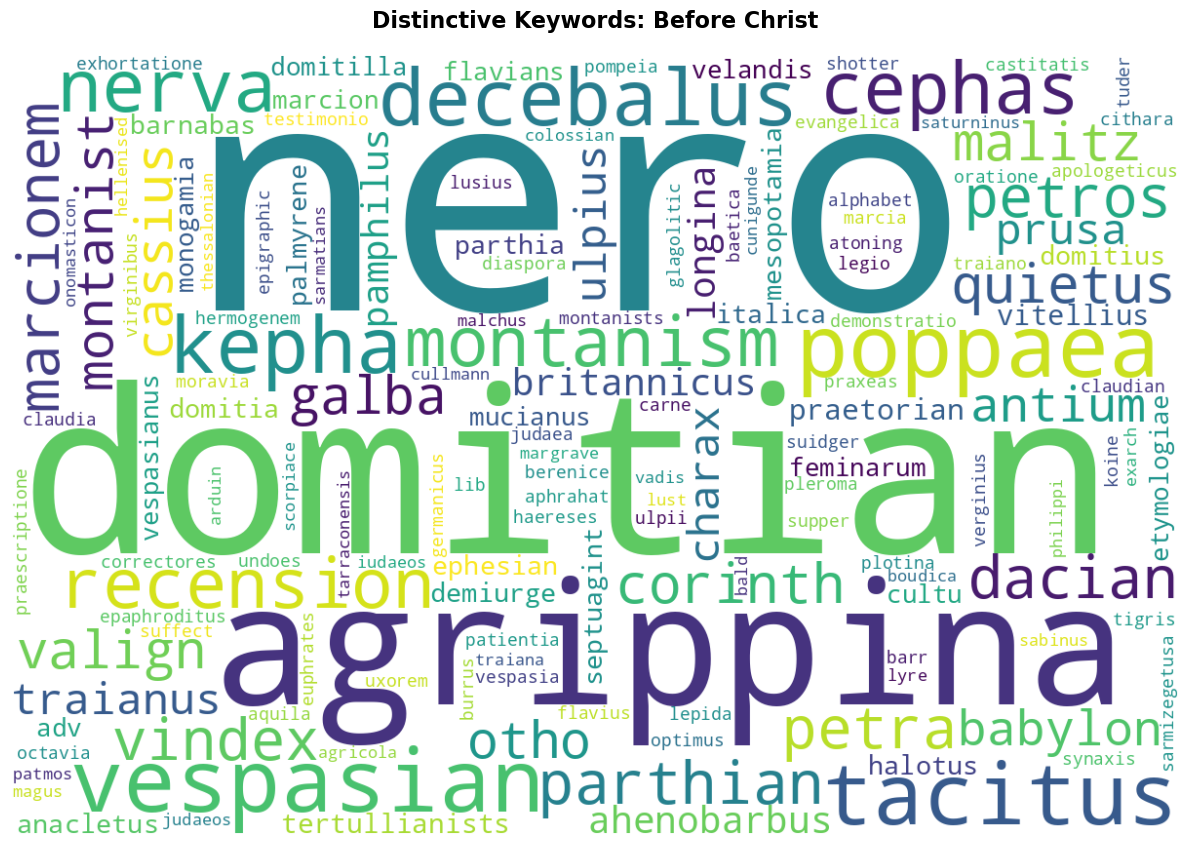

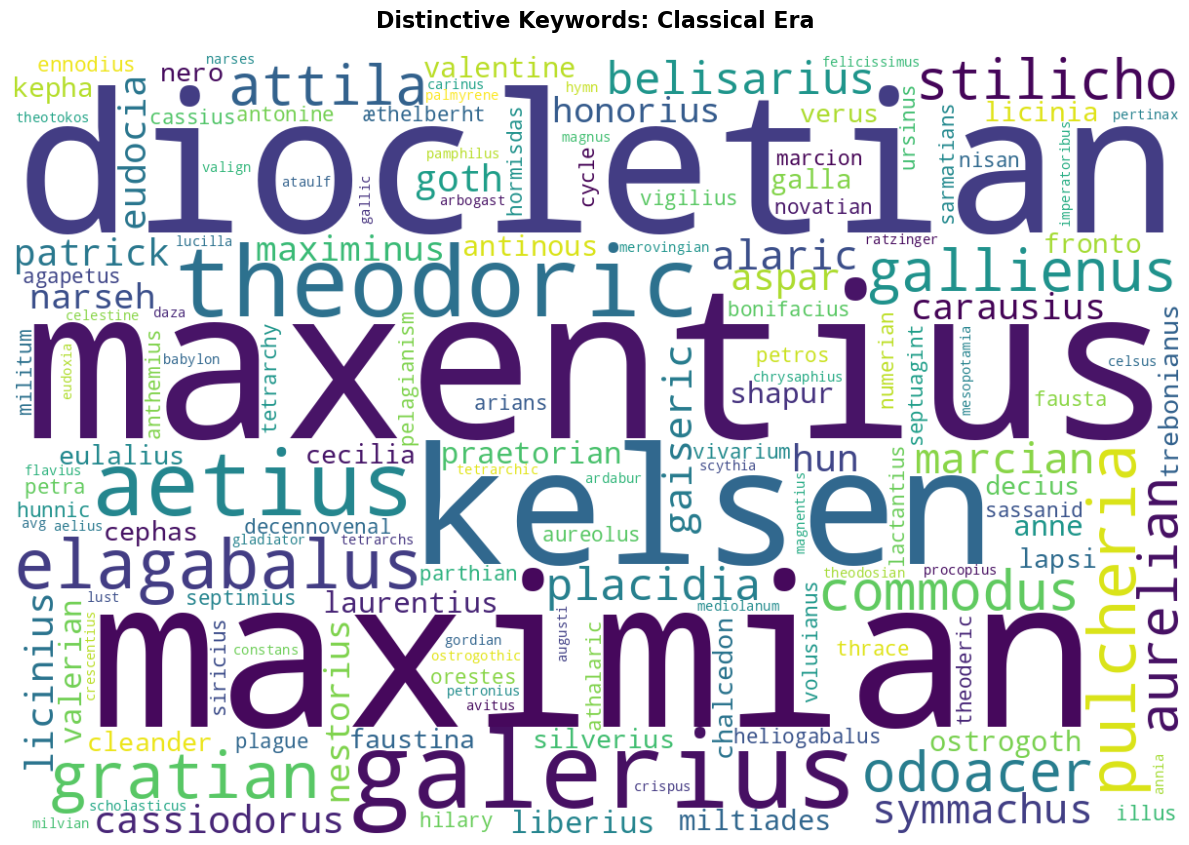

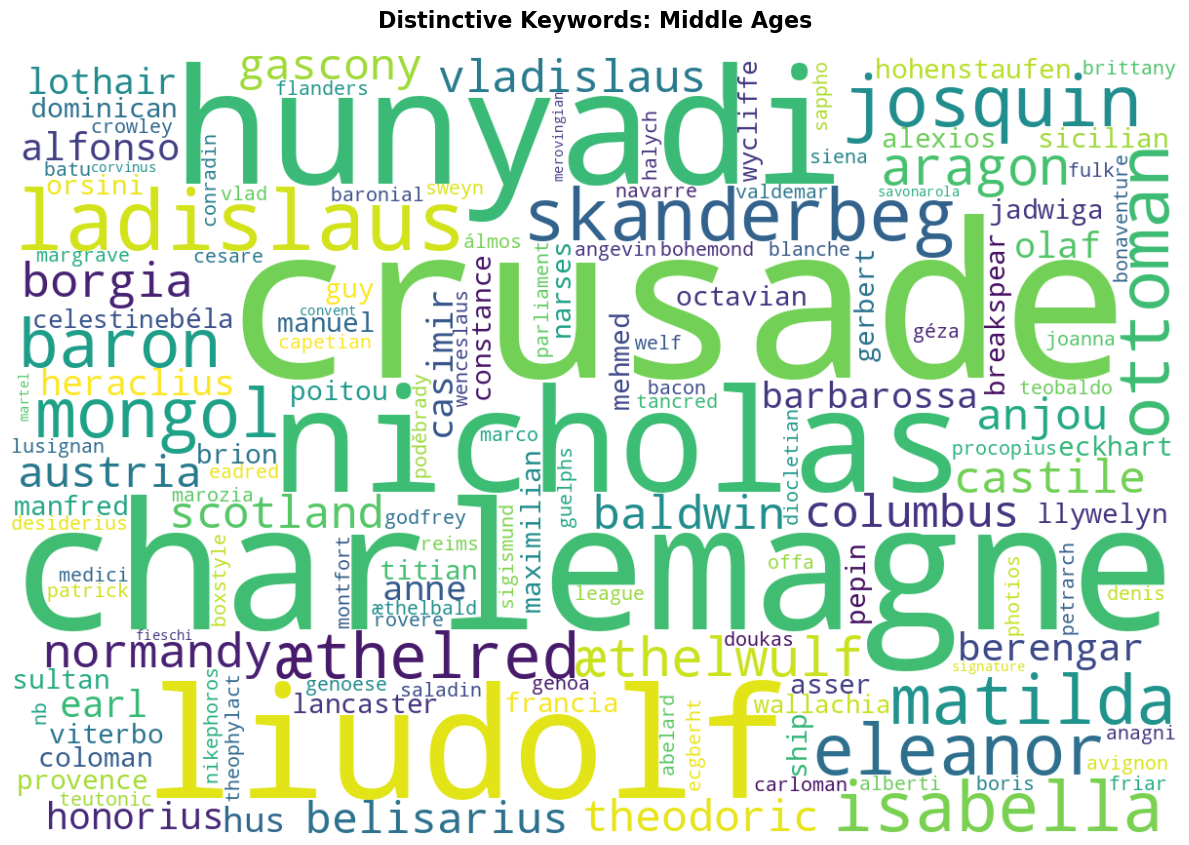

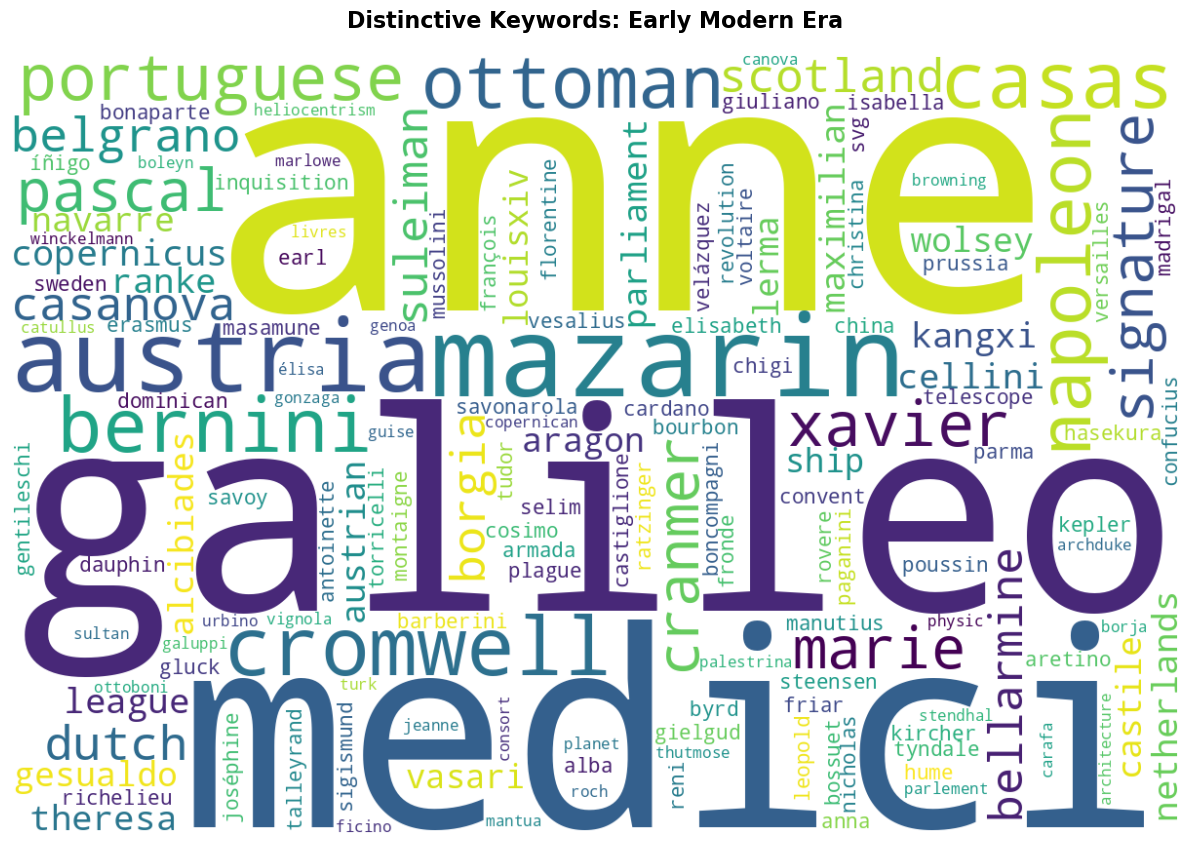

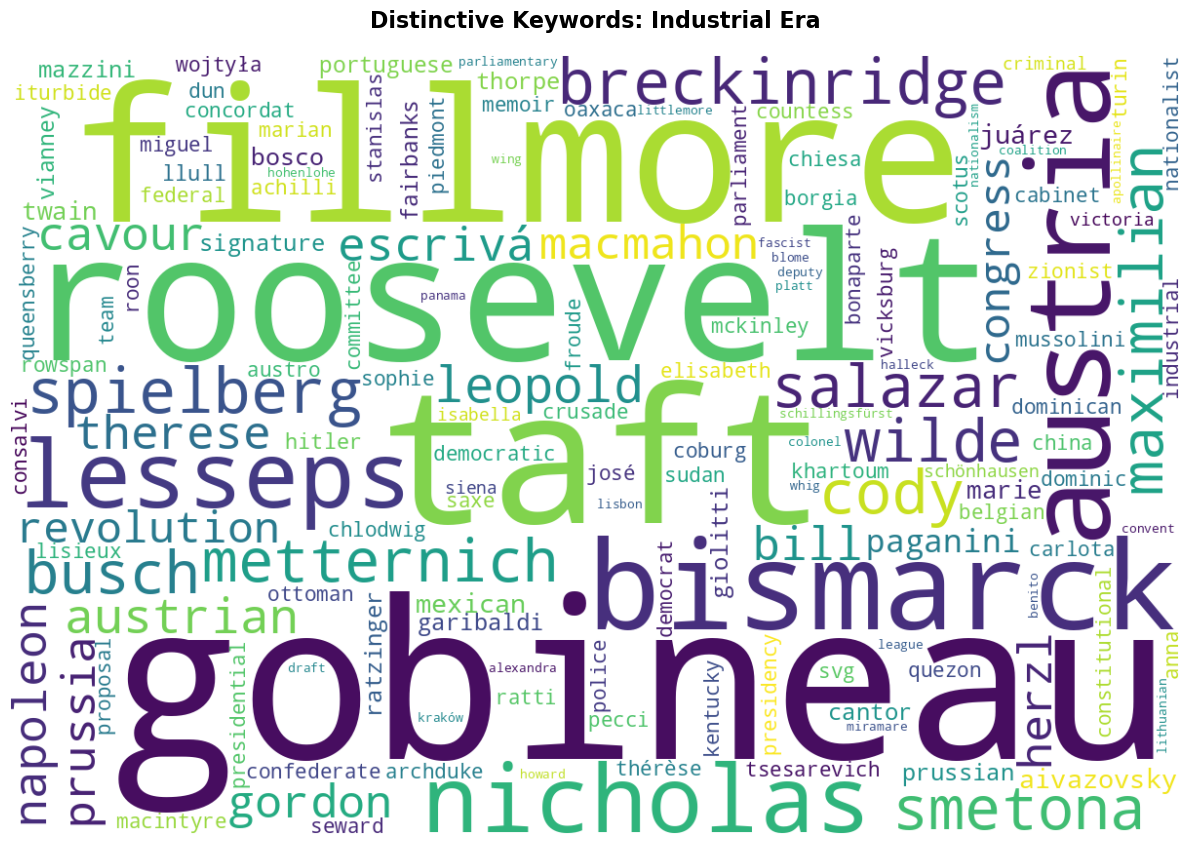

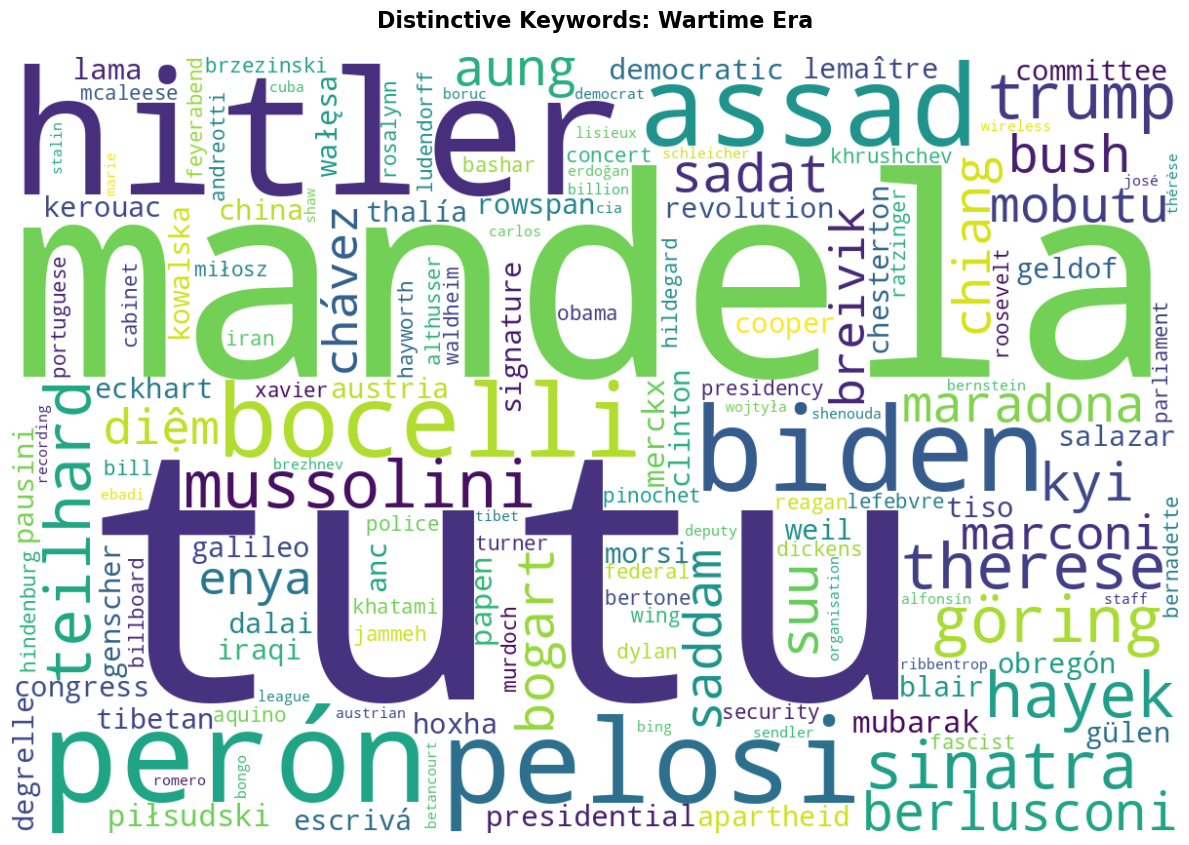

Cannot generate WordCloud: Input weight dictionary is empty.
Cannot generate WordCloud: Input weight dictionary is empty.


In [247]:
visualize_all_pope_eras(popes_in_periods, network)

The differences between the eras are now clearly visible, utilizing TF-IDF with the context specific stopwords.

In [248]:
def compare_2_eras(era1, era2):
    return dict((k,popes_in_periods[k]) for k in (era1, era2) if k in popes_in_periods)

As an experiment, we compare 2 eras below without calculating the TF-IDF for all texts. This means the weights will be slightly different and thus the visualizations will also differ from the full comparison.

Auto-detected 20840 specific stopwords (appearing in >70% of docs).
Examples removed: ['magie', 'vi', 'succeed', 'misplaced', 'opposing']


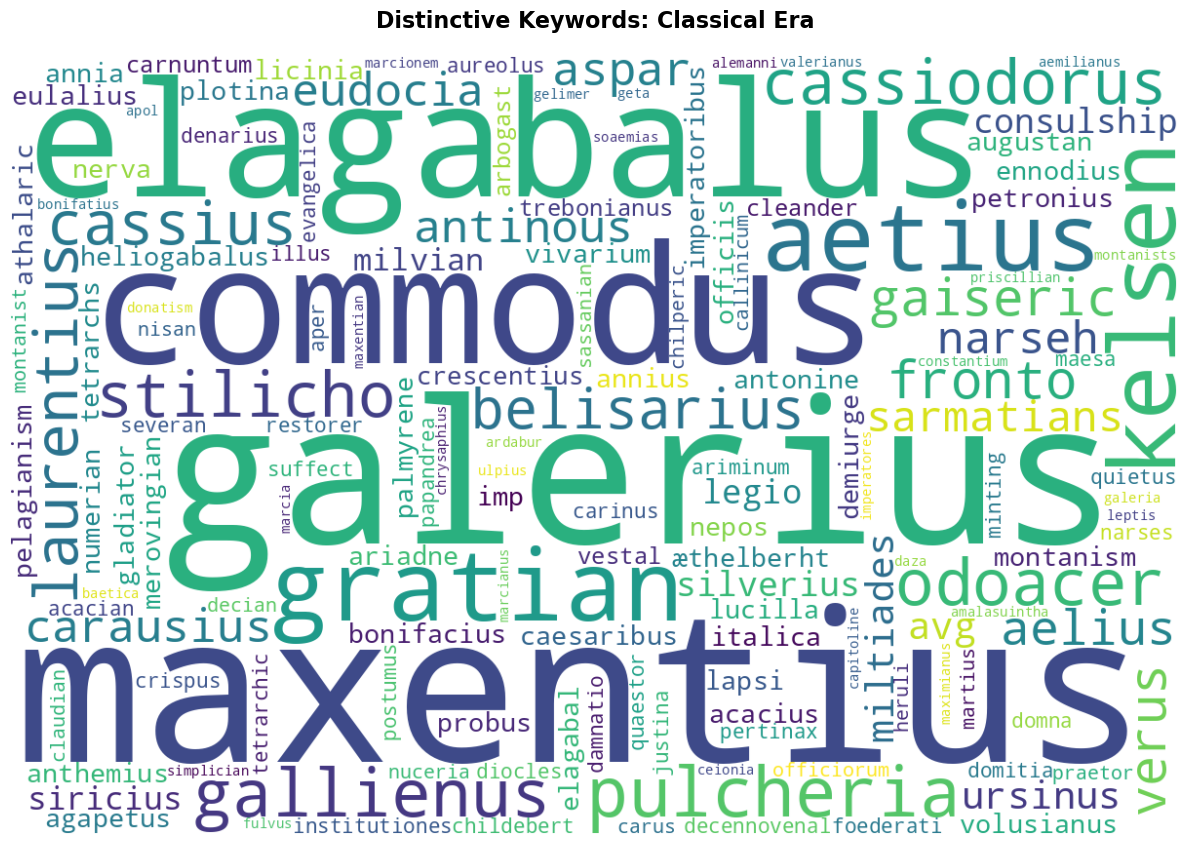

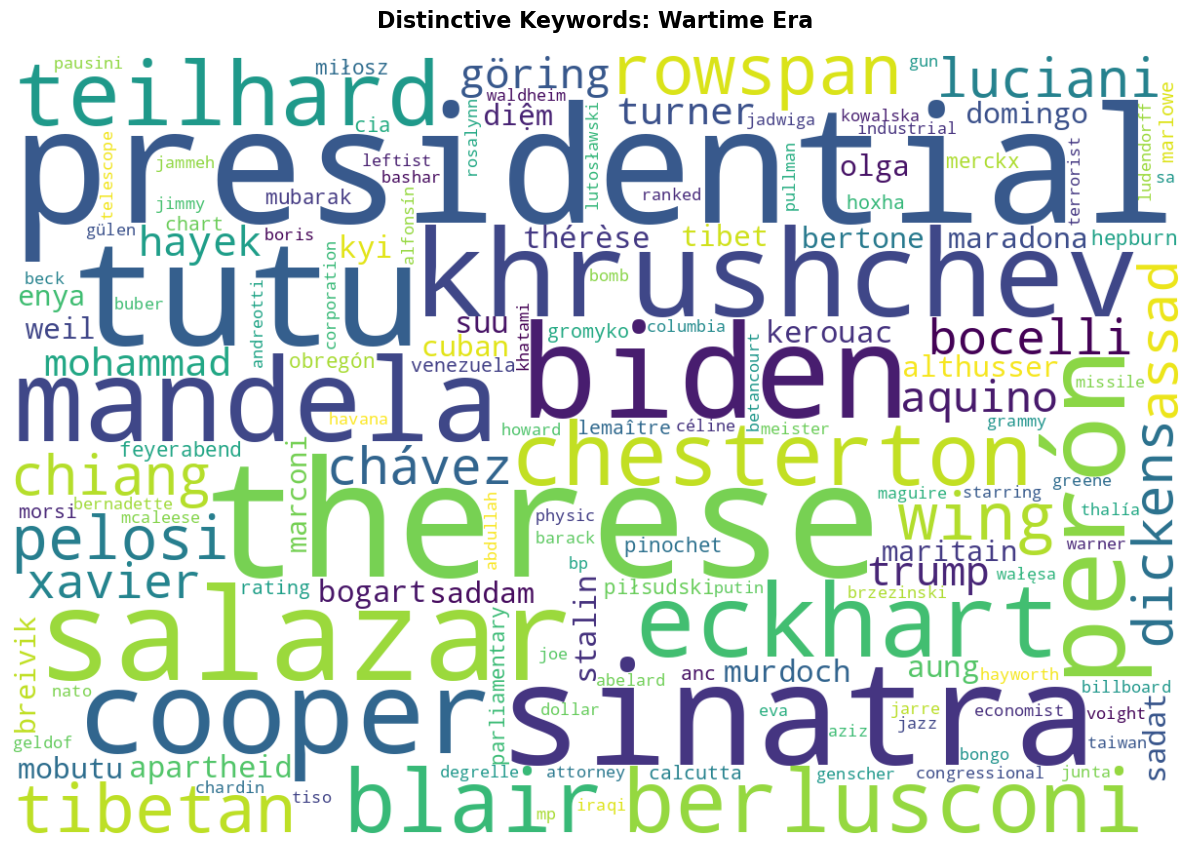

In [249]:
visualize_all_pope_eras(compare_2_eras("Classical Era", "Wartime Era"), network)

In [ ]:
folder_path = "wikipages"

# A utility function to fix some filenames
def batch_fix_filenames(target_folder, target_names):
    # Get list of files currently on disk
    try:
        files_on_disk = os.listdir(target_folder)
    except FileNotFoundError:
        print(f"Error: Folder '{target_folder}' not found.")
        return

    count_fixed = 0

    for correct_name in target_names:
        correct_filename = f"{correct_name}.txt"
        
        # Check if the clean file already exists
        if correct_filename in files_on_disk:
            continue
            
        # If not found, look for a "messy" match
        matches = difflib.get_close_matches(correct_filename, files_on_disk, n=1, cutoff=0.6)
        
        if matches:
            messy_filename = matches[0]
            
            # Construct full paths
            old_path = os.path.join(target_folder, messy_filename)
            new_path = os.path.join(target_folder, correct_filename)
            
            try:
                os.rename(old_path, new_path)
                print(f"Fixed: '{messy_filename}'  ->  '{correct_filename}'")
                
                # Update our local list so we don't try to fix it again
                files_on_disk.remove(messy_filename)
                files_on_disk.append(correct_filename)
                count_fixed += 1
                
            except OSError as e:
                print(f"Failed to rename {messy_filename}: {e}")
        else:
            print(f"Could not find any file resembling: {correct_filename}")

    print(f"Complete. Renamed {count_fixed} files.")


We observe that a significant amount of the words related to eras are names. There are a few that are well-known and expected to show up in their respective eras related to Popes such as Gallileo, Nero or Trump. However some names stood out as unexpected "guests". Two that caought our attention were Tutu and Charlemagne. In the following sections we will analyse these characters more deeply to find out more about their roles in this network.

## Focusing on hidden figures

First we find Desomond Tutu in our network

In [250]:
# Find Desmond Tutu node
tutu_node = None
for node in network.nodes():
    node_name = network.nodes[node].get('Name', '')
    if 'Desmond Tutu' in node_name:
        tutu_node = node
        print(f"Found: {node_name}")
        break

if tutu_node:
    tutu_data = network.nodes[tutu_node]
    print(f"\nDESMOND TUTU")
    print(f"Name: {tutu_data.get('Name')}")
    print(f"Birth Year: {tutu_data.get('birthyear')}")
    print(f"Death Year: {tutu_data.get('deathyear')}")
    print(f"Birth City: {tutu_data.get('birthcity')}")
    print(f"Occupation: {tutu_data.get('occupation')}")


Found: Desmond Tutu

DESMOND TUTU
Name: Desmond Tutu
Birth Year: 1931.0
Death Year: 2018.0
Birth City: KLERKSDORP
Occupation: RELIGIOUS FIGURE


It is important to note that Desmond Tutu died in 2021, our dataset has a cutoff at 2018, so the people alive after 2018 are still shown with 2018 death yer. https://en.wikipedia.org/wiki/Desmond_Tutu

In [252]:
# Analyze Tutu's importance in the network
print(f"\nTUTU'S NETWORK METRICS")
print(f"Degree (connections): {network.degree(tutu_node)}")
print(f"In-Degree: {network.in_degree(tutu_node)}")
print(f"Out-Degree: {network.out_degree(tutu_node)}")



TUTU'S NETWORK METRICS
Degree (connections): 57
In-Degree: 29
Out-Degree: 28


Next we try to capture what is the theme around Tutu using the same method as for the popes.

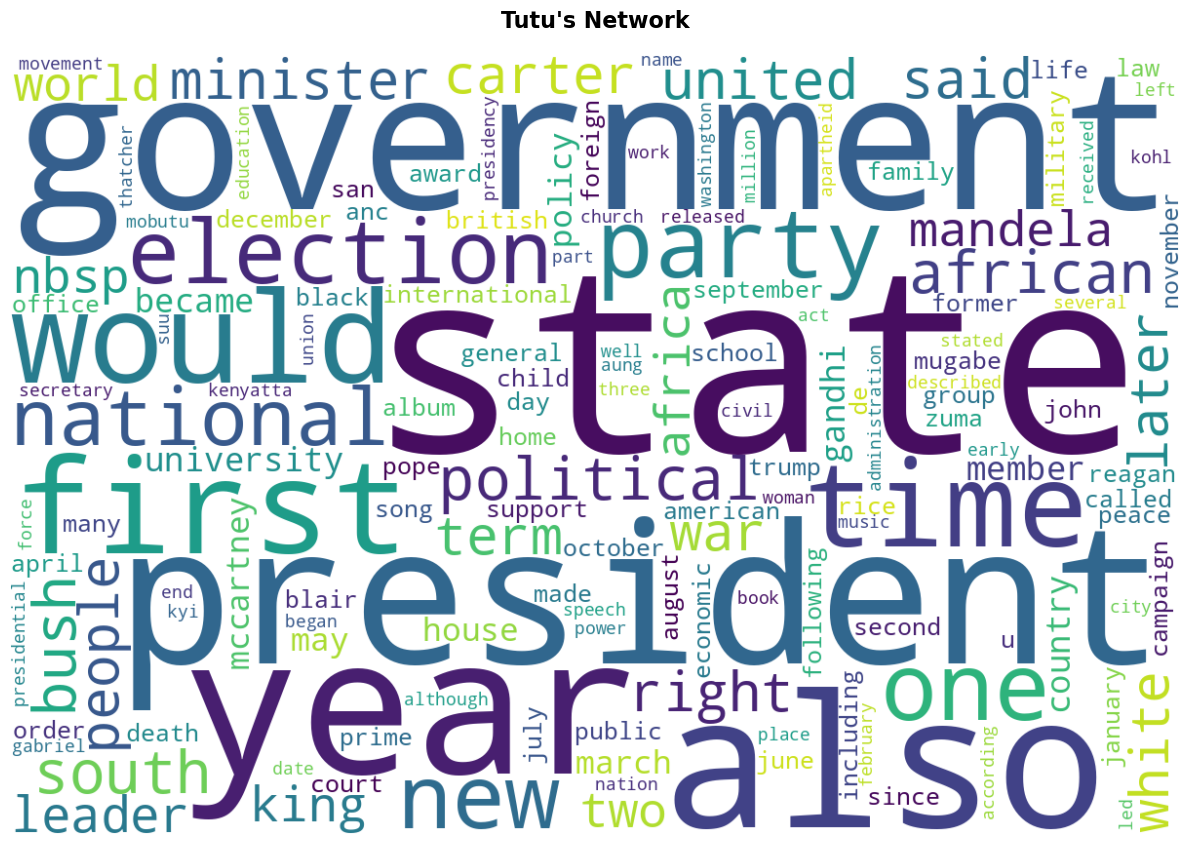

In [253]:
# Combine content from all people connected to Tutu    
neighbor_tokens = []
neighbors = get_undirected_neighbors(tutu_node, network)

for neighbor in neighbors:
    content = get_wikilink_content(neighbor, network)
    if content:
        tokens = clean_and_tokenize(content)
        neighbor_tokens += tokens

# Create word cloud
create_wordcloud_from_tokens(
    neighbor_tokens,
    title="Tutu's Network",
    colormap='viridis'
)

This yields results as expected. The ties around Africa, state and government show in line with the wikipedia article of Desmond Tutu.

In [254]:
# Check if Tutu bridges different communities

undirected_net = network.to_undirected()

# Is Tutu an articulation point?
articulation_points = list(nx.articulation_points(undirected_net))
is_bridge = tutu_node in articulation_points

print(f"Is Tutu an articulation point (bridge)? {is_bridge}")

temp_net = undirected_net.copy()
temp_net.remove_node(tutu_node)

components_before = len(list(nx.connected_components(undirected_net)))
components_after = len(list(nx.connected_components(temp_net)))

print(f"\nImpact of removing Tutu:")
print(f"  Components before: {components_before}")
print(f"  Components after: {components_after}")
print(f"  Network would split into {components_after} separate groups")

Is Tutu an articulation point (bridge)? False

Impact of removing Tutu:
  Components before: 233
  Components after: 233
  Network would split into 233 separate groups


It seems like Tutu is not a critical bridge for the structure of the network, as he doesn't connect any components that would split out if he was not in the network.

Next we analyse the clustering coefficient of Tutu to see if he bridges diverse groups.

In [218]:

undirected_net = network.to_undirected()

# Get all neighbors
neighbors = get_undirected_neighbors(tutu_node, undirected_net)
print(f"Tutu has {len(neighbors)} direct connections")

# Measure local clustering
clustering_coeff = nx.clustering(undirected_net, tutu_node)
print(f"Clustering Coefficient: {clustering_coeff:.2f}")


Tutu has 52 direct connections
Clustering Coefficient: 0.10


With a low clustering coefficient Tutu seems to bridge more diverse groups instead of being in a clique.

In [255]:
def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

We investigate the neighbors of Tutu more with regards to the eras they lived in and their occupations.

In [256]:
neighbors = get_undirected_neighbors(tutu_node, network)

print(f"\nTUTU'S NEIGHBOR DIVERSITY\n")

neighbor_occupations = {}
neighbor_eras = {}

for neighbor in neighbors:
    occupation = network.nodes[neighbor].get('occupation', 'Unknown')
    birthyear = network.nodes[neighbor].get('birthyear', 0)
    
    # Count occupations
    neighbor_occupations[occupation] = neighbor_occupations.get(occupation, 0) + 1
    
    era = get_era(birthyear)
        
    neighbor_eras[era] = neighbor_eras.get(era, 0) + 1

print("Occupations of Tutu's neighbors:")
for occ, count in sorted(neighbor_occupations.items(), key=lambda x: x[1], reverse=True):
    print(f"  {occ}: {count}")

print(f"\nHistorical eras of Tutu's neighbors:")
for era, count in sorted(neighbor_eras.items(), key=lambda x: x[1], reverse=True):
    print(f"  {era}: {count}")



TUTU'S NEIGHBOR DIVERSITY

Occupations of Tutu's neighbors:
  POLITICIAN: 29
  SOCIAL ACTIVIST: 9
  RELIGIOUS FIGURE: 3
  MUSICIAN: 3
  BUSINESSPERSON: 2
  SINGER: 2
  ATHLETE: 1
  DIPLOMAT: 1
  ACTOR: 1
  WRITER: 1

Historical eras of Tutu's neighbors:
  Wartime (1840-1945): 33
  Post-War (1945-2025): 18
  Early Modern (1450-1760): 1


As visible most of the neighbors are politicians. This is an interesting finding because he himself is a religious figure. This can be attributed to the human rights activism which was a significant part of his work. Most of his connections are born in the same era as him (his birthyear 1931 is part of the wartime era), this is less surprising.

As we discovered Tutu from the people surrounding the popes a logical next step is to investigate his relationship with all popes in the network.

In [ ]:
# Find all pope nodes
pope_nodes = [
    n for n, attr in network.nodes(data=True)
    if isinstance(attr.get("Name"), str) and "Pope" in attr.get("Name") and 
        attr.get("occupation") == "RELIGIOUS FIGURE"
]

In [ ]:

print(f"TUTU'S CONNECTION TO POPES\n")

# Check direct connections to popes
neighbors = get_undirected_neighbors(tutu_node, network)
popes_connected_to_tutu = [n for n in neighbors if n in pope_nodes]

print(f"Popes directly connected to Tutu: {len(popes_connected_to_tutu)}")

if popes_connected_to_tutu:
    print("\nDirect pope connections:")
    for pope_node in popes_connected_to_tutu:
        pope_name = network.nodes[pope_node].get('Name')
        pope_year = network.nodes[pope_node].get('birthyear')
        print(f"  - {pope_name} ({pope_year})")

# Check shortest paths from Tutu to each pope
print(f"\nShortest paths from Tutu to popes:")
undirected_net = network.to_undirected()

path_lengths = []
for pope_node in pope_nodes:
    if nx.has_path(undirected_net, tutu_node, pope_node):
        path_length = nx.shortest_path_length(undirected_net, tutu_node, pope_node)
        path_lengths.append(path_length)
        pope_name = network.nodes[pope_node].get('Name')

if path_lengths:
    avg_path_length = sum(path_lengths) / len(path_lengths)
    print(f"\nAverage path length to popes: {avg_path_length:.2f}")
    print(f"Min: {min(path_lengths)}, Max: {max(path_lengths)}")

TUTU'S CONNECTION TO POPES

Total popes in network: 260
Popes directly connected to Tutu: 2

Direct pope connections:
  - Pope Benedict XVI (1927.0)
  - Pope John XXIII (1881.0)

Shortest paths from Tutu to popes:

Average path length to popes: 3.33
Min: 1, Max: 5


We get an average path length of 3.33 which seems small, but is actually in line with a scale-free network. https://networksciencebook.com/chapter/4#ultra-small
It is important to note that the comparison here is just for indication, as we only analyzed average path lengths from a single node to designated other nodes. Based on this there might be people who have a shorter path length to the popes. We are continuing with this direction.

In [ ]:
undirected_net = network.to_undirected()

In [ ]:
print(f"SHORTEST PATHS TO POPES\n")

path_stats = []

# GATHER DATA
for node in network.nodes():
    node_data = network.nodes[node]
    node_name = node_data.get('Name', 'Unknown')
    occupation = node_data.get('occupation', 'Unknown')
    
    # Filter
    if occupation == "RELIGIOUS FIGURE":
        continue
    
    # Calculate paths
    path_lengths = []
    for pope_node in pope_nodes:
        if nx.has_path(undirected_net, node, pope_node):
            path_len = nx.shortest_path_length(undirected_net, node, pope_node)
            path_lengths.append(path_len)
    
    # Store valid data
    if path_lengths and len(path_lengths) >= 5:
        avg_path = sum(path_lengths) / len(path_lengths)
        
        path_stats.append({
            'Rank': 0,
            'Name': node_name,
            'Occupation': occupation,
            'Avg Path': round(avg_path, 2),
            'Reachable': len(path_lengths),
            'Min': min(path_lengths),
            'Max': max(path_lengths)
        })



SHORTEST PATHS TO POPES

Found 10513 non-religious figures connected to popes

 Rank               Name  Occupation  Avg Path  Reachable  Min  Max
    1 Augustine of Hippo PHILOSOPHER      2.48        260    1    4
    2        Charlemagne  POLITICIAN      2.51        260    1    4
    3     Thomas Aquinas PHILOSOPHER      2.51        260    1    4
    4               Bede   HISTORIAN      2.52        260    1    4
    5             Origen PHILOSOPHER      2.62        260    1    4


In [ ]:
df = pd.DataFrame(path_stats)

# Sort by Average Path
df = df.sort_values(by='Avg Path', ascending=True)
df['Rank'] = range(1, len(df) + 1)


cols = ['Rank', 'Name', 'Occupation', 'Avg Path', 'Reachable', 'Min', 'Max']
df = df[cols]

print(f"Found {len(df)} non-religious figures connected to popes\n")

# Print the top 30
print(df.head(5).to_string(index=False))

Found 10513 non-religious figures connected to popes

 Rank               Name  Occupation  Avg Path  Reachable  Min  Max
    1 Augustine of Hippo PHILOSOPHER      2.48        260    1    4
    2        Charlemagne  POLITICIAN      2.51        260    1    4
    3     Thomas Aquinas PHILOSOPHER      2.51        260    1    4
    4               Bede   HISTORIAN      2.52        260    1    4
    5             Origen PHILOSOPHER      2.62        260    1    4


We find here that Charlemagne who we found previously with the wordclouds is also present here as one of the people with the shortest paths to the popes. We go deeper into his statistics.

In [ ]:
target_name = "Charlemagne"

target_stat = next((stat for stat in path_stats if stat['Name'] == target_name), None)

print(f"Average path to popes: {target_stat['Avg Path']:.2f} hops")
print(f"Can reach: {target_stat['Reachable']} popes")
print(f"Closest pope: {target_stat['Min']} hops away")
print(f"Farthest pope: {target_stat['Max']} hops away")

Average path to popes: 2.51 hops
Can reach: 260/260 popes
Closest pope: 1 hops away
Farthest pope: 4 hops away


Next we look at the people who are on the most pope-pope shortest paths to build on our previous findings. Our expectation is that smoe of the figures will be the same as in the previous experiment, as the 2 metrics we are looking at are closely related. We use the betweenness_centrality_subset from networkx as we are only interested about the pope-pope paths here

In [ ]:


# Calculate Centrality (Standard NetworkX)
pope_pair_betw = betweenness_centrality_subset(
    undirected_net, 
    sources=pope_nodes, 
    targets=pope_nodes, 
    normalized=False
)

df = pd.DataFrame.from_dict(pope_pair_betw, orient='index', columns=['betweenness'])

# map the graph data directly to new columns in the DataFrame
df['occupation'] = df.index.map(lambda n: network.nodes[n].get('occupation'))
df['name'] = df.index.map(lambda n: network.nodes[n].get('Name'))
df['degree'] = df.index.map(dict(undirected_net.degree()))


# Filter for non-religious figures and sort by betweenness
top_brokers = df[df['occupation'] != 'RELIGIOUS FIGURE'].sort_values(by='betweenness', ascending=False)

print("\nTop non-religious nodes on pope-pope shortest paths:")
print(top_brokers[['name', 'betweenness', 'degree']].head(5))




Top non-religious nodes on pope-pope shortest paths:
                    name  betweenness  degree
512          Charlemagne  1653.906629      99
73    Augustine of Hippo  1632.523142     108
4710      Thomas Aquinas  1334.848877      85
7919                Bede   869.104654      51
5854         Justinian I   784.142126      50


Charlemagne also appears here as one of the top figures with the highest betwenness in this setup.

Finally we are also curious about people who bridge different eras in line with our era definitions. We look at the connections to see which eras they are from.

In [265]:
# Find nodes that bridge the most eras (temporal bridges)
# For each node, find which eras its neighbors belong to
undirected_net = network.to_undirected()
era_bridges = []

for node in network.nodes():
    node_name = network.nodes[node].get('Name', 'Unknown')
    node_birth = network.nodes[node].get('birthyear')
    node_era = get_era(node_birth)
    node_occupation = network.nodes[node].get('occupation', 'Unknown')
    
    # Get all neighbors
    try:
        neighbors = get_undirected_neighbors(node, undirected_net)
    except:
        continue
    
    if not neighbors:
        continue
    
    # Find which eras the neighbors belong to
    neighbor_eras = set()
    for neighbor in neighbors:
        neighbor_birth = network.nodes[neighbor].get('birthyear')
        neighbor_era = get_era(neighbor_birth)
        if neighbor_era != 'Unknown':
            neighbor_eras.add(neighbor_era)
    
    # Only include nodes that bridge 2+ eras
    if len(neighbor_eras) >= 2:
        era_bridges.append({
            'node_id': node,
            'name': node_name,
            'occupation': node_occupation,
            'birth_era': node_era,
            'birth_year': node_birth,
            'eras_spanned': neighbor_eras,
            'num_eras': len(neighbor_eras),
            'degree': len(neighbors),
            'neighbors_per_era': {era: sum(1 for nb in neighbors if get_era(network.nodes[nb].get('birthyear')) == era) for era in neighbor_eras}
        })

In [ ]:
# Sort by number of eras spanned
era_bridges.sort(key=lambda x: x['num_eras'], reverse=True)

print(f"\nFound {len(era_bridges)} people who bridge across multiple eras\n")
print(f"{'Rank':<6} {'Name':<40} {'Birth Era':<35} {'Eras Spanned':<6} {'Degree':<8} {'Occupation':<25}")
print("-" * 130)

for rank, bridge in enumerate(era_bridges[:5], 1):

    eras_str = str(bridge['num_eras'])

    print(f"{rank:<6} {bridge['name'][:38]:<40} {str(bridge['birth_era'])[:33]:<35} "

          f"{eras_str:<6} {bridge['degree']:<8} {bridge['occupation'][:23]:<25}")


Found 7846 people who bridge across multiple eras

Rank   Name                                     Birth Era                           Eras Spanned Degree   Occupation               
----------------------------------------------------------------------------------------------------------------------------------
1      Zoroaster                                Before Christ (< 30)                7      49       WRITER                   
2      Jacques Derrida                          Wartime (1840-1945)                 7      60       PHILOSOPHER              
3      Charlemagne                              Middle Ages (476-1450)              7      99       POLITICIAN               
4      Mao Zedong                               Wartime (1840-1945)                 7      98       POLITICIAN               
5      Søren Kierkegaard                        Industrial Era (1760-1840)          7      69       PHILOSOPHER              


We see Charlemagne also appears as a top figure here. It is worth to point out that he has connections from all of our defined eras.

Latly an additional experiment is included which were not emphasized in the main report but are also related. It is about finding out which people bridge the largest time gaps in terms of their connections.

In [210]:
temporal_bridges = []

for node in network.nodes():
    node_name = network.nodes[node].get('Name', 'Unknown')
    node_birth = network.nodes[node].get('birthyear')
    node_occupation = network.nodes[node].get('occupation', 'Unknown')
    
    try:
        neighbors = get_undirected_neighbors(node, undirected_net)
    except:
        continue
    
    if len(neighbors) < 2:
        continue
    
    # Get birth years of all neighbors
    neighbor_years = []
    for neighbor in neighbors:
        nb_year = network.nodes[neighbor].get('birthyear')
        if nb_year and isinstance(nb_year, (int, float)):
            neighbor_years.append(float(nb_year))
    
    if len(neighbor_years) >= 2:
        time_span = max(neighbor_years) - min(neighbor_years)
        avg_time_gap = time_span / len(neighbor_years)
        
        temporal_bridges.append({
            'node_id': node,
            'name': node_name,
            'occupation': node_occupation,
            'birth_year': node_birth,
            'time_span': time_span,
            'avg_gap': avg_time_gap,
            'degree': len(neighbors),
            'earliest_neighbor': min(neighbor_years),
            'latest_neighbor': max(neighbor_years)
        })

In [272]:


df_temp = pd.DataFrame(temporal_bridges)
# Sort by time_span
df_temp = df_temp.sort_values(by='time_span', ascending=False)

# Handle Missing Values
def format_year(val):
    try:
        # Check if value exists and is not NaN/None
        if pd.notna(val) and val: 
            return str(int(val))
        return '?'
    except (ValueError, TypeError):
        return '?'

# Apply formatting
df_temp['Birth Year'] = df_temp['birth_year'].apply(format_year)
earliest = df_temp['earliest_neighbor'].apply(format_year)
latest = df_temp['latest_neighbor'].apply(format_year)

# Create Columns
df_temp['Time Span'] = df_temp['time_span'].astype(int).astype(str) + " yrs"
df_temp['Earliest-Latest'] = earliest + " - " + latest


columns_to_show = ['name', 'Birth Year', 'Time Span', 'degree', 'Earliest-Latest', 'occupation']
df_final = df_temp[columns_to_show].rename(columns={'degree': 'Degree'})

top_5 = df_final.head(5).reset_index(drop=True)
top_5.index = top_5.index + 1  # Start rank at 1
top_5.index.name = 'Rank'

print("\nTop people bridging the largest time gaps:\n")
print(top_5)


Top people bridging the largest time gaps:

                     name Birth Year Time Span  Degree Earliest-Latest  \
Rank                                                                     
1             Emma Watson       1990  5498 yrs      39    -3500 - 1998   
2     William Shakespeare       1564  5496 yrs     325    -3500 - 1996   
3              Tom Cruise       1962  5494 yrs     106    -3500 - 1994   
4        Darren Aronofsky       1969  5492 yrs      43    -3500 - 1992   
5                     Ham      -3443  5492 yrs       7    -3500 - 1992   

            occupation  
Rank                    
1                ACTOR  
2               WRITER  
3                ACTOR  
4        FILM DIRECTOR  
5     RELIGIOUS FIGURE  
